# **FingerVein dataset exploration (MMCBNU_6000)**


In [9]:
# here I can put the eventual colab code

# **Useful modules import**
First of all, it is necessary to import useful modules used during the project.

In [10]:
import io
import zipfile
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pypdf import PdfReader

# **Configuration**
We point to the dataset archive. The datasets live next to the project, in `../proposal_helpers/proj_files/`. Adjust `DATA_ZIP_DIR` if you move them.

In [11]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ZIP_DIR = PROJECT_ROOT.parent / 'proposal_helpers' / 'proj_files'
FV_ZIP = DATA_ZIP_DIR / 'MMCBNU_6000.zip'

assert FV_ZIP.exists(), f'FingerVein archive not found: {FV_ZIP}'
print('Using archive:', FV_ZIP)

Using archive: /Users/muni/Documents/uni/DL/proposal_helpers/proj_files/MMCBNU_6000.zip


# **Utility functions**
- **list_images** returns the list of `.bmp` entries inside the archive;
- **parse_path** extracts `(subject, finger, capture)` from an image path;
- **load_image** reads one `.bmp` from the archive into a NumPy array.

In [12]:
def list_images(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        return sorted(n for n in z.namelist() if n.lower().endswith('.bmp'))


def parse_path(name):
    # .../Captured images/<subject>/<finger>/<capture>.bmp
    parts = name.split('/')
    subject = parts[-3]
    finger = parts[-2]
    capture = parts[-1].replace('.bmp', '')
    return subject, finger, capture


def load_image(zip_path, name):
    with zipfile.ZipFile(zip_path) as z:
        return np.array(Image.open(io.BytesIO(z.read(name))))

# **Dataset overview**
Let's count images, subjects and fingers, and check a single image's shape.

In [13]:
images = list_images(FV_ZIP)
meta = [parse_path(n) for n in images]

subjects = sorted({m[0] for m in meta})
fingers = sorted({m[1] for m in meta})

print(f'Total images : {len(images)}')
print(f'Subjects     : {len(subjects)}  (e.g. {subjects[:5]} ...)')
print(f'Fingers      : {len(fingers)} -> {fingers}')

sample = load_image(FV_ZIP, images[0])
print(f'Image shape  : {sample.shape}  dtype={sample.dtype}  '
      f'min={sample.min()} max={sample.max()}')

Total images : 12000
Subjects     : 100  (e.g. ['001', '002', '003', '004', '005'] ...)
Fingers      : 6 -> ['L_Fore', 'L_Middle', 'L_Ring', 'R_Fore', 'R_Middle', 'R_Ring']
Image shape  : (480, 640)  dtype=uint8  min=0 max=225


# **Subject demographics (the labels)**
Unlike a PhysioNet record, MMCBNU_6000 ships **no `subject-info.csv`**. The per-subject demographics live in `Description of MMCBNU_6000.pdf`, which contains an *Information table* of the 100 volunteers with columns **Order, Age, Nationality, Gender, Blood type**.

We read that PDF straight from the archive (no extraction) and parse the table into a DataFrame. `Order` (1..100) maps one-to-one onto the image subject folders `001..100`, and **`Age` is our regression target**.

In [8]:
def load_subject_info(zip_path):
    """Parse the 100-row 'Information table' from the description PDF inside the archive."""
    with zipfile.ZipFile(zip_path) as z:
        pdf_name = next(n for n in z.namelist() if n.lower().endswith('.pdf'))
        reader = PdfReader(io.BytesIO(z.read(pdf_name)))
    text = '\n'.join((page.extract_text() or '') for page in reader.pages)

    rows = []
    for line in text.splitlines():
        toks = line.split()
        # a data row starts with: <order:int> <age:int> ...
        if len(toks) >= 4 and toks[0].isdigit() and toks[1].isdigit():
            gi = next((i for i, t in enumerate(toks[2:], 2) if t in ('M', 'F')), None)
            if gi is None:
                continue
            rows.append({
                'Order': int(toks[0]),
                'Subject': f'{int(toks[0]):03d}',          # matches the image folders
                'Age': int(toks[1]),
                'Nationality': ' '.join(toks[2:gi]),
                'Gender': toks[gi],
                'Blood type': ' '.join(toks[gi + 1:]) or None,
            })
    return pd.DataFrame(rows).sort_values('Order').reset_index(drop=True)


info = load_subject_info(FV_ZIP)
print('subjects:', len(info))
info.head()

subjects: 100


,Order,Subject,Age,Nationality,Gender,Blood type
0,1,001,22,China,F,B
1,2,002,24,China,M,AB
2,3,003,22,China,M,O
3,4,004,27,Afghanistan,M,A
4,5,005,47,China,M,NaN


# **Age and gender distribution**
Same target-distribution check as the PPG notebook. The age range is narrow (mostly twenties, a few older outliers), which will matter for the age-regression error analysis.

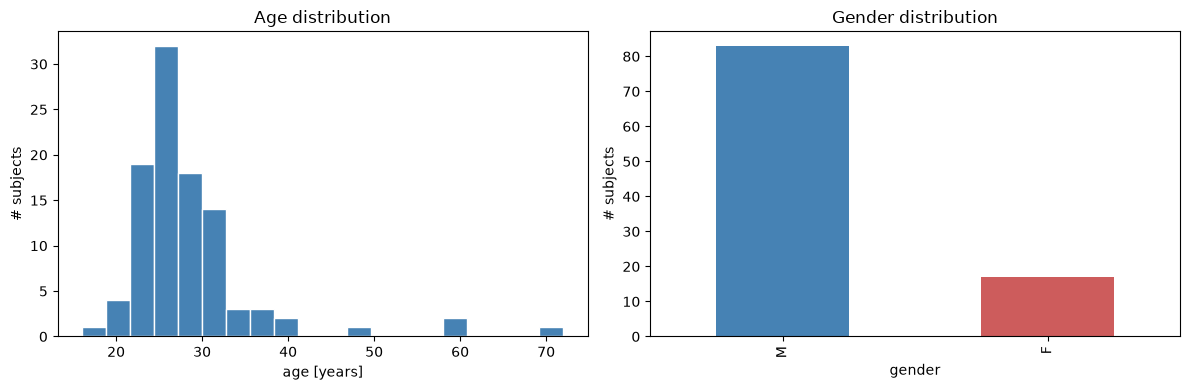

count    100.0
mean      28.4
std        7.7
min       16.0
25%       25.0
50%       27.0
75%       30.0
max       72.0
Name: Age, dtype: float64


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(info['Age'], bins=20, color='steelblue', edgecolor='white')
ax1.set_title('Age distribution')
ax1.set_xlabel('age [years]')
ax1.set_ylabel('# subjects')

info['Gender'].value_counts().plot.bar(ax=ax2, color=['steelblue', 'indianred'])
ax2.set_title('Gender distribution')
ax2.set_xlabel('gender')
ax2.set_ylabel('# subjects')
plt.tight_layout()
plt.show()

print(info['Age'].describe().round(1))

# **A grid of finger-vein images**
We display the 6 fingers of a single subject to appreciate the vein patterns.

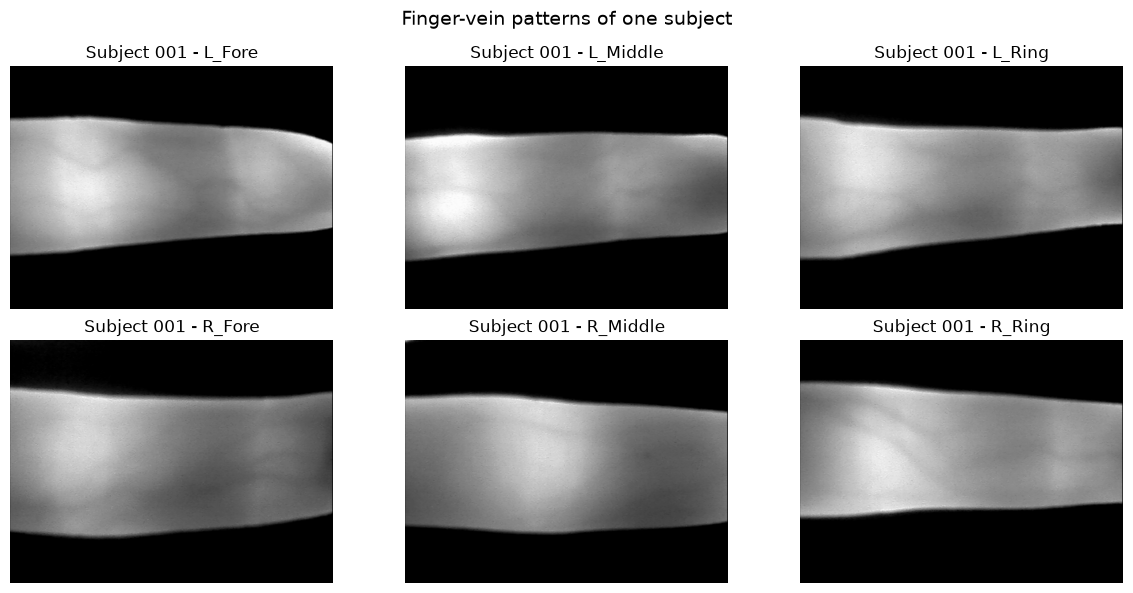

In [15]:
subject = subjects[0]
subject_imgs = [n for n in images if parse_path(n)[0] == subject]
# one image per finger
first_per_finger = {}
for n in subject_imgs:
    f = parse_path(n)[1]
    first_per_finger.setdefault(f, n)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (finger, name) in zip(axes.ravel(), sorted(first_per_finger.items())):
    ax.imshow(load_image(FV_ZIP, name), cmap='gray')
    ax.set_title(f'Subject {subject} - {finger}')
    ax.axis('off')
fig.suptitle('Finger-vein patterns of one subject', fontsize=14)
plt.tight_layout()
plt.show()

# **Same finger across different subjects**
Inter-subject variability of the vein pattern (this is what makes the modality biometric).

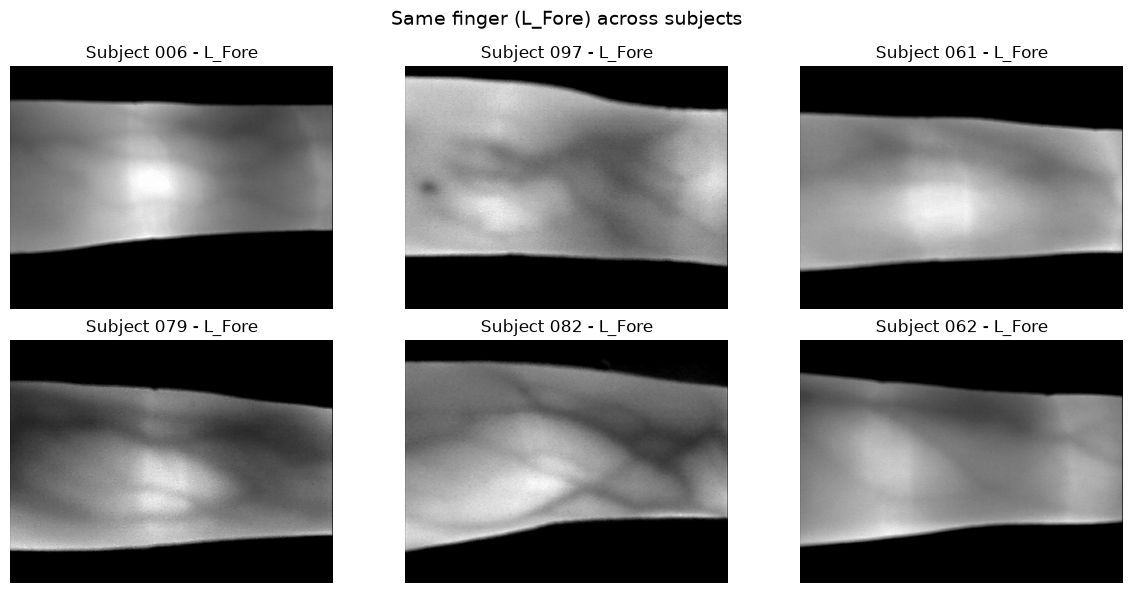

In [16]:
finger = fingers[0]
chosen = random.sample(subjects, 6)
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, subj in zip(axes.ravel(), chosen):
    name = next(n for n in images if parse_path(n)[:2] == (subj, finger))
    ax.imshow(load_image(FV_ZIP, name), cmap='gray')
    ax.set_title(f'Subject {subj} - {finger}')
    ax.axis('off')
fig.suptitle(f'Same finger ({finger}) across subjects', fontsize=14)
plt.tight_layout()
plt.show()

# **Pixel intensity distribution**
Understanding the illumination/contrast of the raw images helps design the preprocessing (ROI extraction, contrast normalization) described in the proposal.

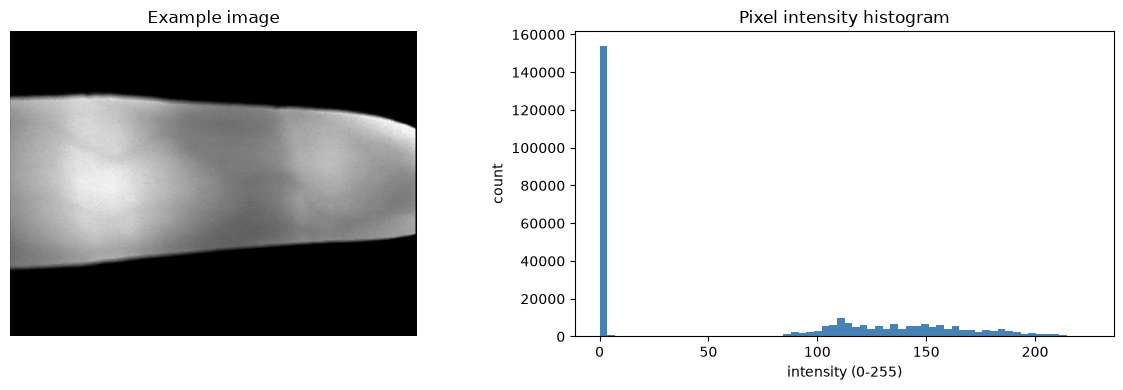

In [17]:
img = load_image(FV_ZIP, images[0])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(img, cmap='gray')
ax1.set_title('Example image')
ax1.axis('off')
ax2.hist(img.ravel(), bins=64, color='steelblue')
ax2.set_title('Pixel intensity histogram')
ax2.set_xlabel('intensity (0-255)')
ax2.set_ylabel('count')
plt.tight_layout()
plt.show()